In [1]:
def calculate_pareto_front(points):
    sorted_points = sorted(points, key=lambda x: x['auc'], reverse=True)
    pareto_front = []
    max_time = float('inf')
    
    for point in sorted_points:
        if point['predict_time_per_row_ms'] < max_time:
            pareto_front.append(point)
            max_time = point['predict_time_per_row_ms']
    
    return pareto_front


In [2]:
import pandas as pd

df_H10h1 = pd.read_csv("./H10h1.csv")
df_H10h3 = pd.read_csv("./H10h3.csv")
df_H10h5 = pd.read_csv("./H10h5.csv")

pf_H10h1 = pd.read_csv("./H10h1_pf.csv")
pf_H10h3 = pd.read_csv("./H10h3_pf.csv")
pf_H10h5 = pd.read_csv("./H10h5_pf.csv")


In [3]:
from pprint import pprint

colors = {'StackedEnsemble': 'red', 'XGBoost': 'blue', 'GBM': 'green', 'DRF': 'orange', 'DeepLearning': 'purple', 'GLM': 'yellow'}

def get_points_from_df(df):
    points = []
    for index, row in df.iterrows():
        color = None
        if row['algo'] in colors.keys():
            color = colors[row['algo']]
        else:
            color = 'gray'
        point = {
            'model_id': row['model_id'],
            'auc':row['auc'],
            'predict_time_per_row_ms': row['predict_time_per_row_ms'],
            'algo':row['algo'],
            'color':color
            }
        points.append(point)
    return points

In [4]:
pf_H10h1

,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
0,StackedEnsemble_AllModels_1_AutoML_1_20230623_...,0.991897,0.109300,0.990987,0.040288,0.175755,0.030890,11261,0.036665,StackedEnsemble
1,StackedEnsemble_BestOfFamily_1_AutoML_1_202306...,0.991523,0.112512,0.990652,0.041181,0.179223,0.032121,6391,0.016692,StackedEnsemble
2,XGBoost_grid_1_AutoML_1_20230623_111421_model_3,0.990674,0.119021,0.989439,0.043940,0.183920,0.033827,5041,0.004047,XGBoost
3,XGBoost_3_AutoML_1_20230623_111421,0.990673,0.120230,0.989245,0.042807,0.182281,0.033226,4033,0.003618,XGBoost
4,XGBoost_grid_1_AutoML_1_20230623_111421_model_2,0.990062,0.118764,0.988286,0.042889,0.182481,0.033299,3150,0.003105,XGBoost
5,GLM_1_AutoML_1_20230623_111421,0.911369,0.434971,0.884643,0.150948,0.349037,0.121827,6327,0.002951,GLM


In [5]:
pf_H10h1_selected = pf_H10h1[['model_id','auc','predict_time_per_row_ms','algo']]
pf_H10h1_selected['color'] = pf_H10h1_selected['algo'].apply(lambda x: colors[x])

pf_H10h3_selected = pf_H10h3[['model_id','auc','predict_time_per_row_ms','algo']]
pf_H10h3_selected['colors'] = pf_H10h3_selected['algo'].apply(lambda x: colors[x])

pf_H10h5_selected = pf_H10h5[['model_id','auc','predict_time_per_row_ms','algo']]
pf_H10h5_selected['colors'] = pf_H10h5_selected['algo'].apply(lambda x: colors[x])


/tmp/ipykernel_72857/1750254533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pf_H10h1_selected['color'] = pf_H10h1_selected['algo'].apply(lambda x: colors[x])
/tmp/ipykernel_72857/1750254533.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pf_H10h3_selected['colors'] = pf_H10h3_selected['algo'].apply(lambda x: colors[x])
/tmp/ipykernel_72857/1750254533.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [6]:
from pprint import pprint

points_H10h1 = get_points_from_df(df_H10h1)
points_H10h3 = get_points_from_df(df_H10h3)
points_H10h5 = get_points_from_df(df_H10h5)

pareto_front_H10h1 = calculate_pareto_front(points_H10h1)
pareto_front_H10h3 = calculate_pareto_front(points_H10h3)
pareto_front_H10h5 = calculate_pareto_front(points_H10h5)

#pareto_front_H10h1 = pf_H10h1_selected.to_dict(orient='records')
#pareto_front_H10h3 = pf_H10h3_selected.to_dict(orient='records')
#pareto_front_H10h5 = pf_H10h5_selected.to_dict(orient='records')

print(f"Pareto front H10h1")
pprint(pareto_front_H10h1)

print(f"Pareto front H10h3")
pprint(pareto_front_H10h3)

print(f"Pareto front H10h5")
pprint(pareto_front_H10h5)

Pareto front H10h1
[{'algo': 'StackedEnsemble',
  'auc': 0.993682,
  'color': 'red',
  'model_id': 'StackedEnsemble_AllModels_1_AutoML_1_20230622_152146',
  'predict_time_per_row_ms': 0.045128},
 {'algo': 'StackedEnsemble',
  'auc': 0.993028,
  'color': 'red',
  'model_id': 'StackedEnsemble_BestOfFamily_1_AutoML_1_20230622_152146',
  'predict_time_per_row_ms': 0.019966},
 {'algo': 'XGBoost',
  'auc': 0.992434,
  'color': 'blue',
  'model_id': 'XGBoost_3_AutoML_1_20230622_152146',
  'predict_time_per_row_ms': 0.004399}]
Pareto front H10h3
[{'algo': 'StackedEnsemble',
  'auc': 0.990267,
  'color': 'red',
  'model_id': 'StackedEnsemble_AllModels_1_AutoML_2_20230622_160445',
  'predict_time_per_row_ms': 0.029081},
 {'algo': 'XGBoost',
  'auc': 0.989102,
  'color': 'blue',
  'model_id': 'XGBoost_grid_1_AutoML_2_20230622_160445_model_2',
  'predict_time_per_row_ms': 0.005342},
 {'algo': 'GLM',
  'auc': 0.909837,
  'color': 'yellow',
  'model_id': 'GLM_1_AutoML_2_20230622_160445',
  'predict_

In [7]:
import matplotlib.pyplot as plt

def plot_pareto_front(ax, points, pareto_front):
    
    unique_algo_values = set(item["algo"] for item in points)
    #fig, ax = plt.subplots()

    for algo in unique_algo_values:
        filtered_list = list(filter(lambda item: item["algo"] == algo, points))
        x = [item["predict_time_per_row_ms"] for item in filtered_list]
        y = [item["auc"] for item in filtered_list]
        color = [item["color"] for item in filtered_list]
        ax.scatter(x, y, c=color, label=algo,
                alpha=0.6, edgecolors='none')
        ax.legend(algo)
        ax.set_xlabel("Predict time per row")
        ax.set_ylabel("AUC")

    pareto_time_values = [item["predict_time_per_row_ms"] for item in pareto_front]
    pareto_auc_values = [item["auc"] for item in pareto_front]
    
    ax.plot(pareto_time_values, pareto_auc_values, c='red', label='Pareto Front')
    
    legends = list(unique_algo_values)
    legends.append('Pareto Front')
    legend = ax.legend()
    legend.get_frame().set_alpha(1)
    ax.legend(legends, loc='lower right', bbox_to_anchor=(1.0, 0.0))
    ax.grid(True)

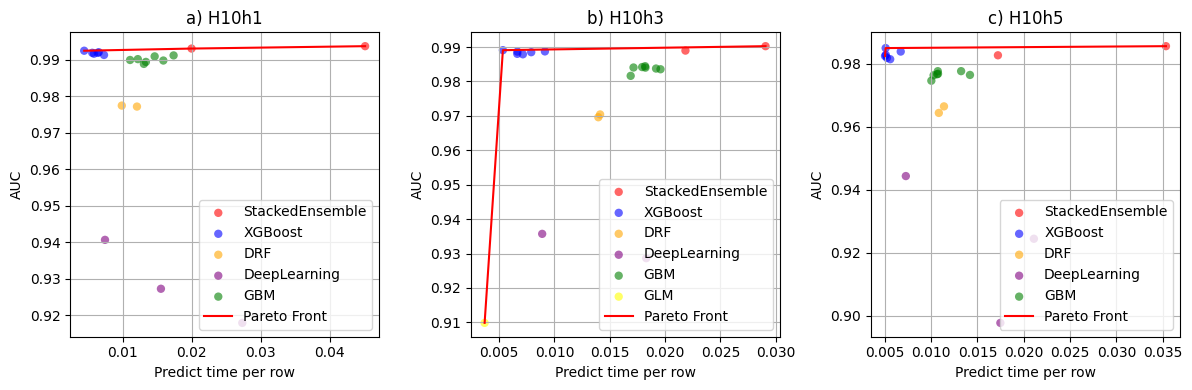

In [8]:
# Crear la figura y los subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

plot_pareto_front(ax1,points_H10h1, pareto_front_H10h1)
ax1.set_title('a) H10h1')

plot_pareto_front(ax2,points_H10h3, pareto_front_H10h3)
ax2.set_title('b) H10h3')

plot_pareto_front(ax3,points_H10h5, pareto_front_H10h5)
ax3.set_title('c) H10h5')

# Ajustar los espacios entre subplots
plt.tight_layout()

# Mostrar el gráfico
plt.show()
